## 3. Average melting per area

 We are creating similar figures to Recreating IMSIP6 BMB melting (credit Helene Seroussi) but instead of using absolut basal melting values, we are insterested in the average melting per shelf area. We group the century average melt rates by the different basal melt rate parameterizations. We investigate also the quadratic non local and quadratic local basal melt rate paramterization further and  group  it  by the different ice sheet models. we show the timeseries  of total melt ,shelf area and average ice shelf metling for  specific models.

In [49]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalars'


In [50]:
df = pd.read_csv('metadata.txt', usecols=[1,2,3,4,5,6,7,8,9])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0


In [51]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]




In [52]:
file_exp[ifile]

'computed_shelfmelt_AIS_NORCE_CISM5-MAR364-ERA-t1_expAE05.nc'

In [53]:
file_exp[0].split("computed_shelfmelt")[-1]

'_AIS_NCAR_CISM1_expAE05.nc'

ComputedScalars/expAE02/shelfmelt/computed_shelfmelt_AIS_VUW_PISM1_s1_expAE02.nc


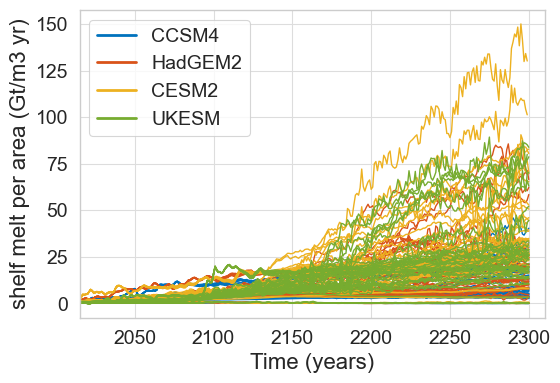

In [54]:


expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists

dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(1,1, figsize = (6,4))

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
#     file_exp2 = os.listdir(f"{computed_name}/{expname}/iareafl")
#     file_exp2 = [file for file in file_exp2 if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
        filename_end =file_exp[ifile].split("computed_shelfmelt")[-1]
        filename2 = f"{computed_name}/{expname}/iareafl/computed_iareafl"+filename_end
        d2 = xr.open_dataset(filename2,decode_times=False )
        data2 = d2.iareafl.values 
        data3 = -(data[:d.time.size]*10**12/900/data2[:d.time.size])

        time = np.arange(2016, 2301)

     

        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]
        if len(data) > 250:

            if data[-1] > 0:
                data = -data

            if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                print(filename)
            else:
#                     aluesend_dict[expname].append(-data[time.size-1])
                plt.plot(d.time,data3 , linewidth=1, color=colors[iexp, :])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = np.mean(data3[i_2100:i_2100+10])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = np.mean(data3[i_2200:i_2200+10])
                df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = np.mean(data3[i_2300:i_2300+10])
        
 
        else:
            print("experiment too short for")
                

        



# ax.set_ylim([0, 2.5 * 10**4])
ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('shelf melt per area (Gt/m3 yr)', fontsize=16)

legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax.set_xlim([2015, 2310])
# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [55]:
df = df[df['melt2100'] != 0]
df

,Climate Forcing,Experiment,GL Melt,Group,Main submission,Melt Parameterisation,Model,Model setup,fileID,melt2100,melt2200,melt2300
0,CCSM4,expAE02,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,3.846958,4.434082,11.587094
1,HadGEM2,expAE03,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,4.320245,9.084336,20.011907
2,CESM2,expAE04,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,5.400574,22.961613,32.703139
3,UKESM,expAE05,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,2.750749,14.788597,22.915809
4,CCSM4,expAE02,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,4.900102,4.897080,31.488571
...,...,...,...,...,...,...,...,...,...,...,...,...
167,UKESM,expAE05,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s3,VUW_PISM2_s3,8.042342,17.413206,18.886054
168,CCSM4,expAE02,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,10.118127,17.021672,25.769870
169,HadGEM2,expAE03,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,13.831773,25.688044,25.193522
170,CESM2,expAE04,Yes,VUW,0.0,Lin,PISM,VUW\_PISM2\_s4,VUW_PISM2_s4,12.998057,19.767161,32.058786


In [56]:
df_original = df


Text(0.5, 1.0, 'melt2300')

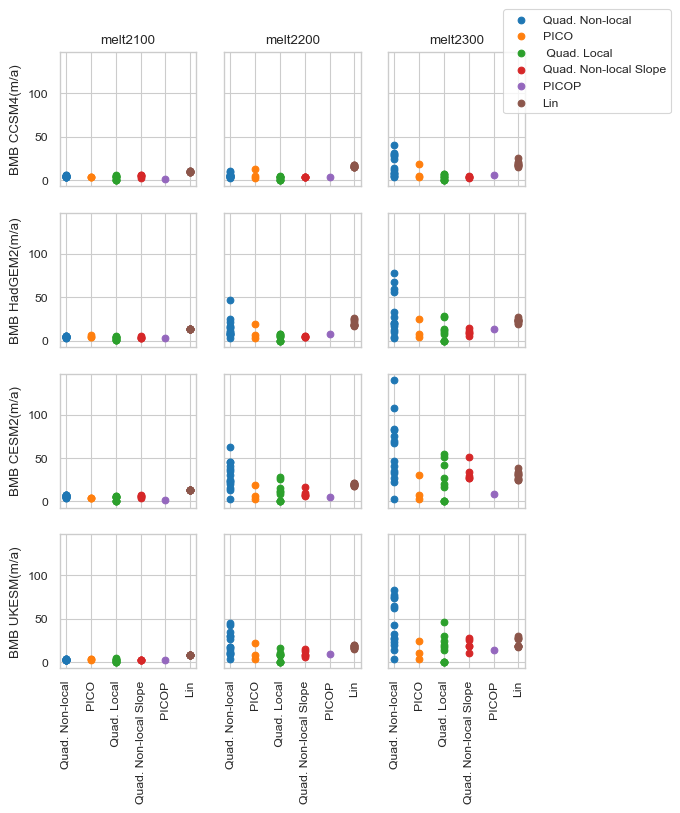

In [57]:

f,ax = plt.subplots(4,3, figsize = (6,8), sharey = True,sharex =True)
unique_models = df['Model'].unique()
# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df[(df['Experiment'] == expname)]
    unique_entries = df_climateforcing['Melt Parameterisation'].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing['Melt Parameterisation']==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp] +'(m/a)')
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

### check quad non local  basal melt rate paramterization  grouped by the different ice sheet model

In [33]:
unique_entries

array(['Quad. Non-local', 'PICO', ' Quad. Local', 'Quad. Non-local Slope',
       'PICOP', 'Lin'], dtype=object)

In [34]:
df1 =df[df['Melt Parameterisation'] == 'Quad. Non-local'] 

In [35]:
df1

,Climate Forcing,Experiment,GL Melt,Group,Main submission,Melt Parameterisation,Model,Model setup,fileID,melt2100,melt2200,melt2300
0,CCSM4,expAE02,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,3.846958,4.434082,11.587094
1,HadGEM2,expAE03,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,4.320245,9.084336,20.011907
2,CESM2,expAE04,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,5.400574,22.961613,32.703139
3,UKESM,expAE05,Sub-Grid,DC,1.0,Quad. Non-local,ISSM,DC\_ISSM,DC_ISSM,2.750749,14.788597,22.915809
4,CCSM4,expAE02,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,4.900102,4.897080,31.488571
5,HadGEM2,expAE03,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,5.420424,14.171380,56.112927
6,CESM2,expAE04,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,6.748961,40.461355,82.375225
7,UKESM,expAE05,Floating condition,DOE,1.0,Quad. Non-local,MALI,DOE\_MALI\_4km,DOE_MALI_4km,3.570863,26.497291,73.722112
8,CCSM4,expAE02,Floating condition,DOE,0.0,Quad. Non-local,MALI,DOE\_MALI\_8km\_Ant95,DOE_MALI_8km_Ant95,5.426298,5.581715,28.030358
9,HadGEM2,expAE03,Floating condition,DOE,0.0,Quad. Non-local,MALI,DOE\_MALI\_8km\_Ant95,DOE_MALI_8km_Ant95,6.035928,21.869719,32.710313


Text(0.5, 1.0, 'melt2300')

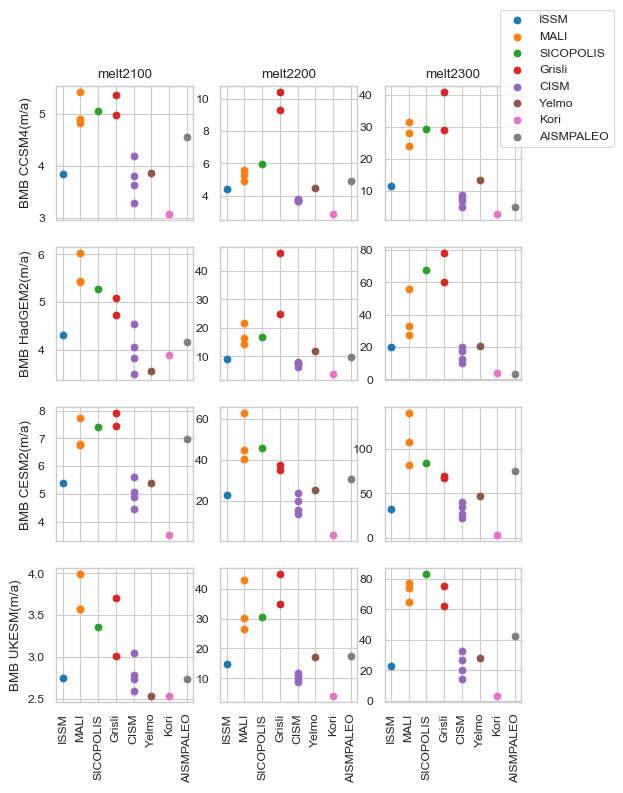

In [37]:
f,ax = plt.subplots(4,3, figsize = (6,8),sharex =True)
#no sharey = True because of very small melt rates 

grouper = 'Model'
unique_models = df_climateforcing['Model'].unique()
# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df1[(df1['Experiment'] == expname)]
    unique_entries = df_climateforcing[grouper].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp] +'(m/a)')
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

## quadratic local

In [38]:
df1 =df[df['Melt Parameterisation'] == ' Quad. Local'] 

   Climate Forcing Experiment             GL Melt Group  Main submission  \
24           CCSM4    expAE02  Floating condition  IMAU              1.0   
28           CCSM4    expAE02  Floating condition  IMAU              0.0   
32           CCSM4    expAE02  Floating condition  IMAU              0.0   
36           CCSM4    expAE02  Floating condition  IMAU              0.0   

   Melt Parameterisation    Model     Model setup         fileID  melt2100  \
24           Quad. Local  UFEMISM  IMAU\_UFEMISM1  IMAU_UFEMISM1  0.446467   
28           Quad. Local  UFEMISM  IMAU\_UFEMISM2  IMAU_UFEMISM2  0.503022   
32           Quad. Local  UFEMISM  IMAU\_UFEMISM3  IMAU_UFEMISM3  0.512561   
36           Quad. Local  UFEMISM  IMAU\_UFEMISM4  IMAU_UFEMISM4  0.481153   

    melt2200  melt2300  
24  0.085024  0.028603  
28  0.109211  0.085141  
32  0.176930  0.089004  
36  0.185568  0.100225  
   Climate Forcing Experiment             GL Melt Group  Main submission  \
25         HadGEM2    expAE

Text(0.5, 1.0, 'melt2300')

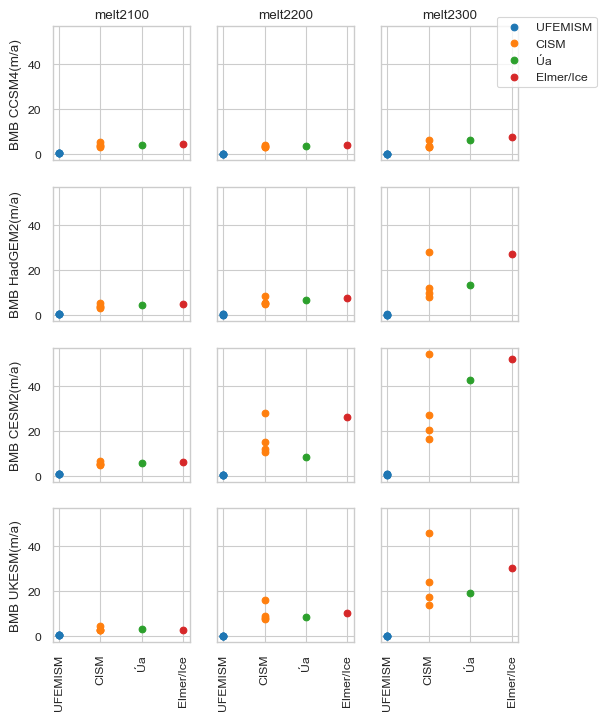

In [39]:
f,ax = plt.subplots(4,3, figsize = (6,8), sharey = True,sharex =True)

grouper = 'Model'
unique_models = df_climateforcing['Model'].unique()
# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df1[(df1['Experiment'] == expname)]
    unique_entries = df_climateforcing[grouper].unique()
    for i, meltparam in enumerate(unique_entries):
        if meltparam == 'UFEMISM':
            print( df_climateforcing[df_climateforcing[grouper]==meltparam ])

        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp] +'(m/a)')
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

In [40]:
unique_entries

array(['UFEMISM', 'CISM', 'Úa', 'Elmer/Ice'], dtype=object)

Text(0.5, 1.0, 'melt2300')

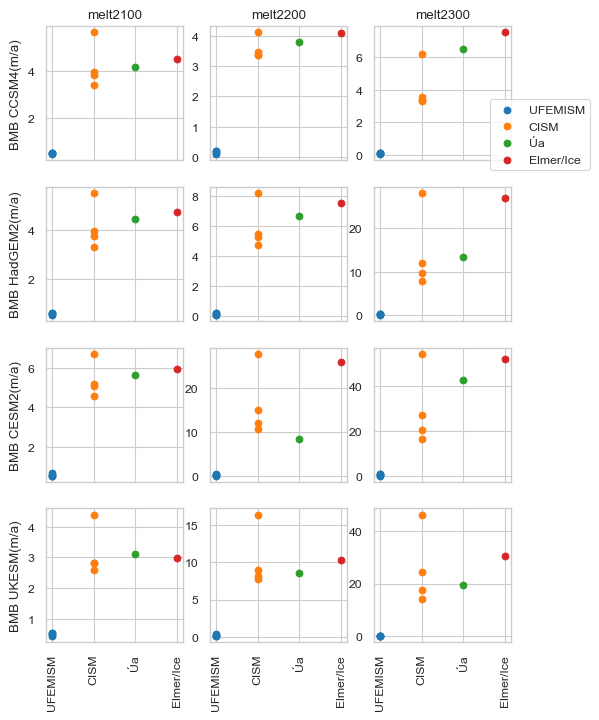

In [41]:
f,ax = plt.subplots(4,3, figsize = (6,8), sharex =True)

grouper = 'Model'
unique_models = df_climateforcing['Model'].unique()
# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    df_climateforcing = df1[(df1['Experiment'] == expname)]
    unique_entries = df_climateforcing[grouper].unique()
    for i, meltparam in enumerate(unique_entries):

        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2100']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,0].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2200']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,1].scatter(x,vals.values,label  = meltparam)
        vals = df_climateforcing.loc[(df_climateforcing[grouper]==meltparam),'melt2300']
        x = np.zeros(len(vals.values))
        x =x +i
        ax[iexp,2].scatter(x,vals.values,label  = meltparam)
    ax[iexp,0].set_ylabel('BMB '+ expnames_plot[iexp] +'(m/a)')
    ax[iexp,0].set_xticks(np.arange(0,len(unique_entries)))
    ax[iexp,0].set_xticklabels(unique_entries)
    ax[iexp,0].tick_params(axis='x', labelrotation=90) 
    ax[iexp,1].tick_params(axis='x', labelrotation=90) 
    ax[iexp,2].tick_params(axis='x', labelrotation=90) 
    

ax[0,2].legend(frameon = True,loc = 0,bbox_to_anchor=[0.8, 0.5])
ax[0,0].set_title('melt2100')
ax[0,1].set_title('melt2200')
ax[0,2].set_title('melt2300')

# what is happening with UFEMSISM ?

Text(0.5, 1.0, 'Timeseries of UFEMISM')

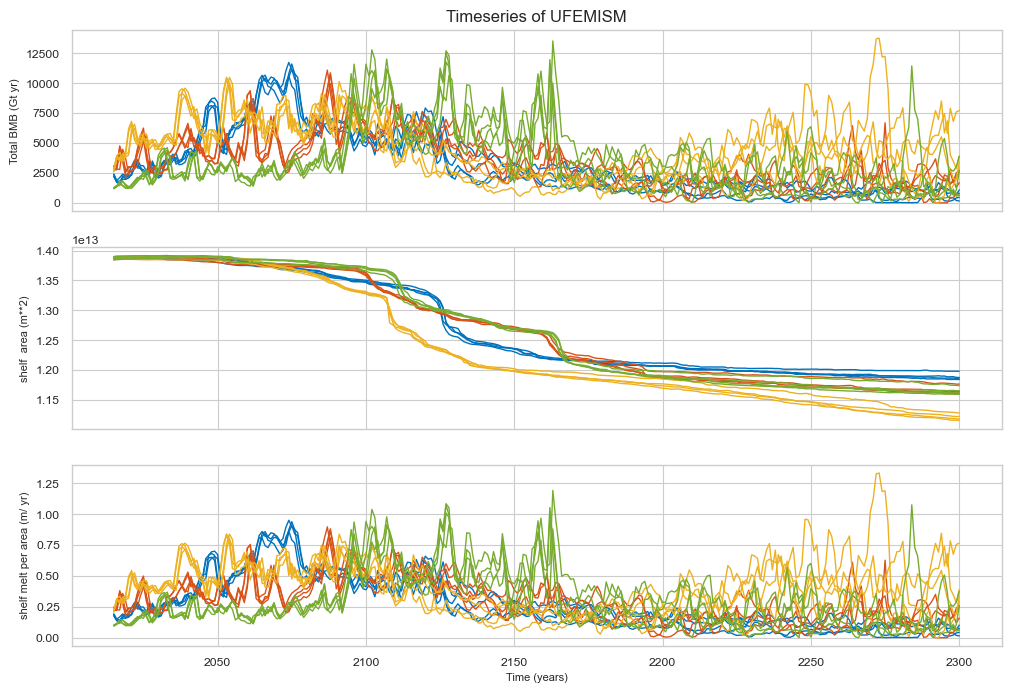

In [47]:



df = pd.read_csv('metadata.txt', usecols=[1,2,3,4,5,6,7,8,9])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0


time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]






file_exp[ifile]

file_exp[0].split("computed_shelfmelt")[-1]



expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists

dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(3,1, figsize = (12,8),sharex = True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
#     file_exp2 = os.listdir(f"{computed_name}/{expname}/iareafl")
#     file_exp2 = [file for file in file_exp2 if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile].split('UFEMISM')) < 2:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
        filename_end =file_exp[ifile].split("computed_shelfmelt")[-1]
        filename2 = f"{computed_name}/{expname}/iareafl/computed_iareafl"+filename_end
        d2 = xr.open_dataset(filename2,decode_times=False )
        data2 = d2.iareafl.values 
        data3 = -(data[:d.time.size]*10**12/900/data2[:d.time.size])

        time = np.arange(2016, 2301)

     

        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]
        if len(data) > 250:

            if data[-1] > 0:
                data = -data

            if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                print(filename)
            else:
#                     aluesend_dict[expname].append(-data[time.size-1])
                ax[0].plot(d.time,-data , linewidth=1, color=colors[iexp, :])

                ax[1].plot(d.time,data2 , linewidth=1, color=colors[iexp, :])
                ax[2].plot(d.time,data3 , linewidth=1, color=colors[iexp, :])
        
    
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = np.mean(data3[i_2100:i_2100+10])
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = np.mean(data3[i_2200:i_2200+10])
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = np.mean(data3[i_2300:i_2300+10])
        
 
        else:
            print("experiment too short for")
                

        

fs =8

# # ax.set_ylim([0, 2.5 * 10**4])
ax[2].set_xlabel('Time (years)', fontsize=fs)
ax[0].set_ylabel('Total BMB (Gt yr)', fontsize=fs)
ax[1].set_ylabel('shelf  area (m**2)', fontsize=fs)
ax[2].set_ylabel('shelf melt per area (m/ yr)', fontsize=fs)
ax[0].set_title('Timeseries of UFEMISM',fontsize = 12)



# legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
# ax.legend(handles=legend_lines, loc='upper left', fontsize=14)

# # plt.legend(expnames, loc='upper left', fontsize=14)
# # plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
# ax.set_xlim([2015, 2310])
# # plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
# ax.tick_params(labelsize=14)
# ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
# ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
# # plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
# plt.show()


#### Compare it to CISM

Text(0.5, 1.0, 'Timeseries of CISM')

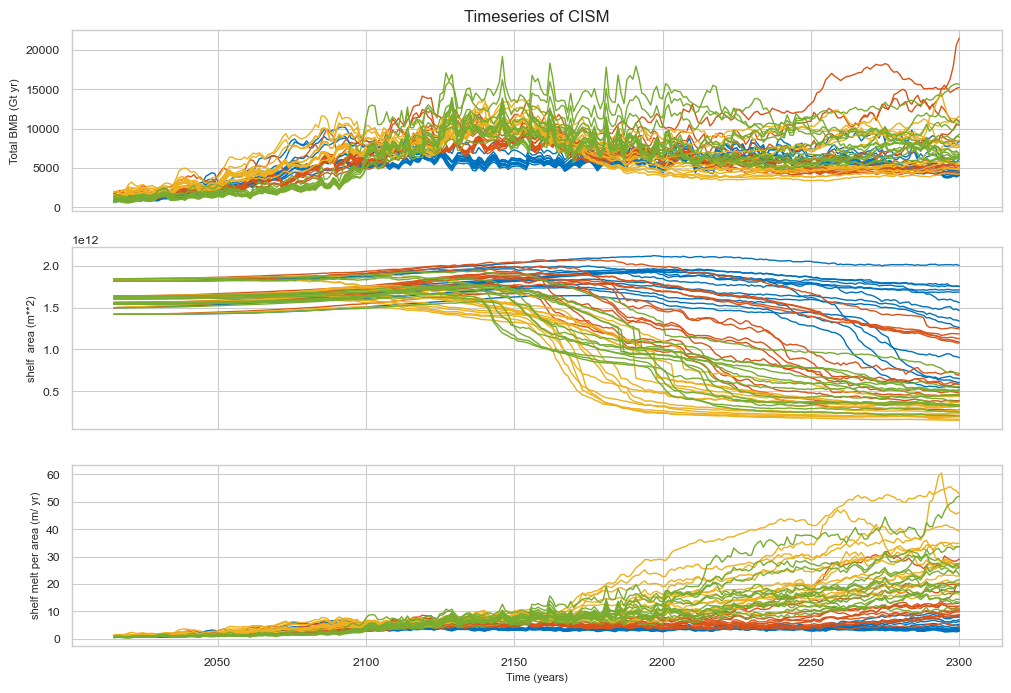

In [48]:



df = pd.read_csv('metadata.txt', usecols=[1,2,3,4,5,6,7,8,9])
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0


time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]






file_exp[ifile]

file_exp[0].split("computed_shelfmelt")[-1]



expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists

dic_all = {}

colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])

f,ax = plt.subplots(3,1, figsize = (12,8),sharex = True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
#     file_exp2 = os.listdir(f"{computed_name}/{expname}/iareafl")
#     file_exp2 = [file for file in file_exp2 if len(file) >= 3]

    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile].split('CISM')) < 2:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
        filename_end =file_exp[ifile].split("computed_shelfmelt")[-1]
        filename2 = f"{computed_name}/{expname}/iareafl/computed_iareafl"+filename_end
        d2 = xr.open_dataset(filename2,decode_times=False )
        data2 = d2.iareafl.values 
        data3 = -(data[:d.time.size]*10**12/900/data2[:d.time.size])

        time = np.arange(2016, 2301)

     

        modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
        modelrun = modelrun[:-1]
        if len(data) > 250:

            if data[-1] > 0:
                data = -data

            if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                print(filename)
            else:
#                     aluesend_dict[expname].append(-data[time.size-1])
                ax[0].plot(d.time,-data , linewidth=1, color=colors[iexp, :])

                ax[1].plot(d.time,data2 , linewidth=1, color=colors[iexp, :])
                ax[2].plot(d.time,data3 , linewidth=1, color=colors[iexp, :])
        
    
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = np.mean(data3[i_2100:i_2100+10])
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = np.mean(data3[i_2200:i_2200+10])
#                 df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = np.mean(data3[i_2300:i_2300+10])
        
 
        else:
            print("experiment too short for")
                

        

fs =8

# # ax.set_ylim([0, 2.5 * 10**4])
ax[2].set_xlabel('Time (years)', fontsize=fs)
ax[0].set_ylabel('Total BMB (Gt yr)', fontsize=fs)
ax[1].set_ylabel('shelf  area (m**2)', fontsize=fs)
ax[2].set_ylabel('shelf melt per area (m/ yr)', fontsize=fs)

ax[0].set_title('Timeseries of CISM',fontsize = 12)

